In [1]:
%reload_ext autoreload
%autoreload 2

import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HDF5_USE_FILE_LOCKING"]= "FALSE"
    
from scipy.constants import mu_0
import MaNTA

from Objective2 import make_objective


import jax
import jax.numpy as jnp
import equinox as eqx 
import yancc

from yancc_wrapper2 import yancc_data

import desc
from desc import set_device
set_device("gpu")
import desc.io
from desc.equilibrium import Equilibrium
from desc.geometry import FourierRZToroidalSurface
from desc.grid import Grid, LinearGrid
from desc.objectives import (
    AspectRatio,
    FixBoundaryR,
    FixBoundaryZ,
    FixCurrent,
    FixPsi,
    ForceBalance,
    LinearObjectiveFromUser,
    ObjectiveFunction,
    ObjectiveFromUser,
    RotationalTransform,
    Volume,
)
from desc.profiles import SplineProfile
import matplotlib.pyplot as plt


Registering cpu implementation for operation get_solution
Registering gpu implementation for operation get_solution
Registering cpu implementation for operation get_adjoint_gradients
Registering gpu implementation for operation get_adjoint_gradients
Registering cpu implementation for operation run
Registering cpu implementation for operation run_ss
Using cache directory: /global/cfs/cdirs/mp217/eatocco/__pycache__
[CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


/global/cfs/cdirs/mp217/eatocco/DESC/desc/__init__.py:151: UserWarning: CUDA_VISIBLE_DEVICES= did not match any physical GPU (id=['0', '1', '2', '3']), falling back to CPU
  warnings.warn(


In [2]:
from Stellarator2 import StellaratorTransport

fname = "stellarator_opt"

eq_name = "eq"

st_config = {
    "SourceCenter": 0.2,
    "SourceHeight": 80.0,
    "SourceWidth": 0.8,
    "EdgeTemperature":0.5,
    "EdgeDensity": 0.0,
    "n0": 1.0,
}

# st_config = {
#     "SourceCenter": 0.2,
#     "SourceHeight": 1000.0,
#     "SourceWidth": 0.8,
#     "EdgeTemperature":0.5,
#     "EdgeDensity": 0.0,
#     "n0": 0.5,
# }

rho_upper = 1.0
rtol = 1e-2
atol = 1e-3

# # %%
solver_config = {
    "OutputFilename": "stellarator_opt",
    "Polynomial_degree": 3,
    "Grid_size": 6,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 1e-2,
    "MinStepSize": 1e-9, 
    "SteadyStateTolerance": 1e-3,
    "restart": False,
    "solveAdjoint": True, 
    "zeroFlux": True,
}


config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

points =  MaNTA.getNodes(solver_config["Lower_boundary"], solver_config["Upper_boundary"], solver_config["Grid_size"], solver_config["Polynomial_degree"])


yancc_rho = jnp.array(points)
yancc_ntheta = 17
yancc_nzeta = 33
yancc_na = 55


# to allow maximum flexibility to match manta, we use a spline with the same control points as manta \
# + axis and lcfs
# initial pressure is all zeros, can change this if desired

pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
desc_pressure = SplineProfile(jnp.zeros_like(pressure_rho), pressure_rho)
print(pressure_rho)
eq = desc.examples.get("ESTELL")
surf = eq.get_surface_at(rho=1)
# surf = FourierRZToroidalSurface(
#     R_lmn=[1, 0.166, 0.1],
#     Z_lmn=[-0.166, -0.1],
#     modes_R=[[0, 0], [1, 0], [0, 1]],
#     modes_Z=[[-1, 0], [0, -1]],
#     NFP=2,
# )


# eq.change_resolution(M=4, N=4,L_grid=len(points), M_grid=4, N_grid=4)# 
eq = Equilibrium(M=8, N=8, Psi=0.5, surface=surf, pressure=desc_pressure)
eq = eq.solve(x_scale="ess")[0]

# eq = desc.io.load("eq_self_consistent_pressure.h5")
# desc_pressure = eq.get_profile('p')
eq_init = eq.copy()

V0 = eq.compute("V")["V"]
# yancc_wrapper = yancc_data.from_eq(points, grid = yancc_grid,rho = yancc_rho, Density=Density, eq=eq_init, nt = yancc_ntheta, nz = yancc_nzeta)
yancc_wrapper = yancc_data.from_eq(points, eq=eq_init, nt = yancc_ntheta, nz = yancc_nzeta, na=yancc_na)

[0.         0.00634337 0.05144305 0.11522362 0.16032329 0.17301004
 0.21810971 0.28189029 0.32698996 0.33967671 0.38477638 0.44855695
 0.49365663 0.50634337 0.55144305 0.61522362 0.66032329 0.67301004
 0.71810971 0.78189029 0.82698996 0.83967671 0.88477638 0.94855695
 0.99365663 1.        ]
Building objective: force
Precomputing transforms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Number of parameters: 856
Number of objectives: 5346

Starting optimization
Using method: lsq-exact
Optimization terminated successfully.
`ftol` condition satisfied. (ftol=1.00e-02)
         Current function value: 7.535e-08
         Total delta_x: 3.111e-01
       

configuring
Successfully created StellaratorTransport object


Total HDG degrees of freedom 79
Configuration done.


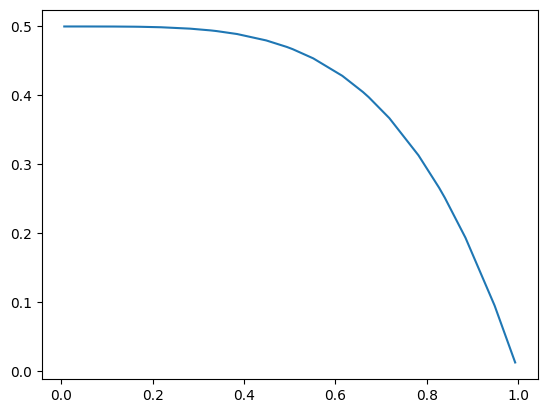

In [3]:


st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
plt.plot(points, 2./3. * st.InitialValue(0, points) / yancc_wrapper.Vp)

In [4]:
st.run()

Setting initial conditions
Residual norm at t = 0: 0
Residual norm at t = 0: 2.03502e-59
Residual norm at t = 0: 0.0317327
Residual norm at t = 0: 0.0297697
Residual norm at t = 0: 0.0279493
Residual norm at t = 0: 0.0262558
Residual norm at t = 0: 0.02468
Residual norm at t = 0: 0.0232133
Residual norm at t = 0: 0.0218477
Residual norm at t = 0: 0.0205769
Residual norm at t = 0: 0.0193944
Residual norm at t = 0: 0.018294
Residual norm at t = 0: 0.0172698
Residual norm at t = 0: 0.0163176
Residual norm at t = 0: 0.015432
Residual norm at t = 0: 0.0146087
Residual norm at t = 0: 0.0138435
Residual norm at t = 0: 0.0131327
Residual norm at t = 0: 0.0124727
Residual norm at t = 0: 0.0118601
Residual norm at t = 0: 0.0112919
Residual norm at t = 0: 0.0107419
Residual norm at t = 0: 0.0107229
Residual norm at t = 0: 0.00356739
Residual norm at t = 0: 0.00353768
Residual norm at t = 0: 0.00351416
Residual norm at t = 0: 0.00349081
Residual norm at t = 0: 0.00346764
Residual norm at t = 0: 0.

Number of Residual Evaluations due to IDACalcIC 36


 IDACalcIC required 36 residual evaluations. Check settings in "stellarator_opt"
Residual norm at t = 1e-05: 0
Residual norm at t = 1e-05: 0.262319
Residual norm at t = 2e-05: 0.00014009
Residual norm at t = 4e-05: 0.00761931
Residual norm at t = 4e-05: 0.00587593
Residual norm at t = 8e-05: 0.000764261
Residual norm at t = 8e-05: 0.0600297
Residual norm at t = 0.00016: 6.1074e-06
Residual norm at t = 0.00016: 0.137625
Residual norm at t = 0.00024: 3.21882e-05
Residual norm at t = 0.0004: 0.0605199
Residual norm at t = 0.0004: 0.386208
Residual norm at t = 0.00056: 0.000176109
Residual norm at t = 0.00072: 0.219111
Residual norm at t = 0.00088: 0.257579
Residual norm at t = 0.00104: 0.177773
Residual norm at t = 0.00104: 0.0950234
Residual norm at t = 0.00136: 0.00366128
Residual norm at t = 0.00136: 0.209761
Residual norm at t = 0.00168: 0.0396482
Residual norm at t = 0.002: 0.111186
Residual norm at t = 0.00232: 0.706745
Residual norm at t = 0.00264: 0.716104
Residual norm at t = 0.0

Writing output at 0.01 ( 27 timesteps )


Residual norm at t = 0.011472: 0.209588
Residual norm at t = 0.011472: 0.146609
Residual norm at t = 0.012624: 0.153574
Residual norm at t = 0.012624: 0.450189
Residual norm at t = 0.013776: 0.094353
Residual norm at t = 0.014928: 0.345326
Residual norm at t = 0.014928: 0.75429
Residual norm at t = 0.014928: 0.626222
Residual norm at t = 0.014928: 0.743912
Residual norm at t = 0.014928: 0.504614
Residual norm at t = 0.01608: 0.000148698
Residual norm at t = 0.017232: 0.520727
Residual norm at t = 0.018384: 0.382861
Residual norm at t = 0.018384: 0.238658
Residual norm at t = 0.019536: 0.0825037
Residual norm at t = 0.02184: 0.100067
Residual norm at t = 0.02184: 1.29555
Residual norm at t = 0.0211163: 0.00123574
Residual norm at t = 0.0211163: 0.719171


...

Residual norm at t = 0.172827: 0.0845305


Writing output at 0.17 ( 57 timesteps )
Steady State achieved at time t = 0.17
Total Number of Timesteps             :57
Total Number of Residual Evaluations  :119
Total Number of Jacobian Computations :17
Computing adjoints


INFO: Computing adjoints for 5722 parameters


Done.


Successfully computed dgdp
5722
24


Initializing yancc wrapper
Flux norm : 146419.5551768456
yancc_wrapper initialized successfully.
configuring
Successfully created StellaratorTransport object


Total HDG degrees of freedom 79
Configuration done.
Setting initial conditions
Residual norm at t = 0: 0
Residual norm at t = 0: 0
Residual norm at t = 0: 4.34764


Number of Residual Evaluations due to IDACalcIC 3


Residual norm at t = 5e-06: 0
Residual norm at t = 5e-06: 0.0340655


Writing output at 5e-06 ( 1 timesteps )
Steady State achieved at time t = 5e-06
Total Number of Timesteps             :1
Total Number of Residual Evaluations  :5
Total Number of Jacobian Computations :3
Computing adjoints


...

Writing output at 5e-06 ( 5 timesteps )
Steady State achieved at time t = 5e-06
Total Number of Timesteps             :5
Total Number of Residual Evaluations  :15
Total Number of Jacobian Computations :7
Computing adjoints


INFO: Computing adjoints for 5722 parameters


Done.
[50877.56684952 50885.49996182 50835.35542033 50721.29383885
 50667.07671666 50378.60796354 49647.05400747 48836.50299113
 48562.02998789 47372.66185341 45122.23001089 43084.70375091
 42454.536584   39954.17420858 35786.31109088 32393.16704565
 31395.22171144 27635.76651159 21863.73127279 17485.75545367
 16224.71442418 11676.90028993  5120.12425222   621.18709802]
Building objective: force
Precomputing transforms


Successfully computed dgdp
5722
24


Timer: Precomputing transforms = 103 ms
Timer: Objective build = 119 ms
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed current
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 169 ms
Timer: LinearConstraintProjection build = 119 ms
Number of parameters: 856
Number of objectives: 5346
Timer: Initializing the optimization = 411 ms

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maximum Allowed Total Δx Norm      : inf
Scaled Termination                 : True
Trust Region Method                : qr
Initial Trust Radius               : 8.690e+01
Maximum Trust Radius 

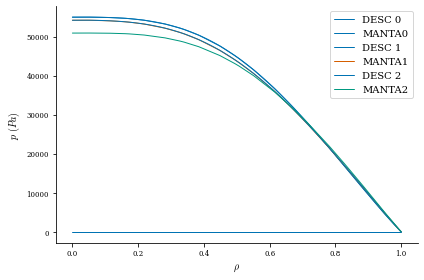

In [5]:
from desc.plotting import plot_1d
from desc.equilibrium import EquilibriaFamily

solver_config = {
    "OutputFilename": fname,
    "Polynomial_degree": 3,
    "Grid_size": 6,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 5e-6,
    "MinStepSize": 1e-10,
    "restart": True,
    "solveAdjoint": True, 
    "zeroFlux": True,
    "SteadyStateTolerance": 1e-4,
}

config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

fig, ax = plt.subplots()

eq2 = eq.copy()
fam2 = EquilibriaFamily(eq2)
niters = 3
for k in range(niters):
    eq2 = eq2.copy()

    fig, ax = plot_1d(eq2, "pressure", label="DESC " + str(k), ax=ax)

    yancc_wrapper = yancc_data.from_eq(points, eq=eq2, nt = yancc_ntheta, nz = yancc_nzeta, na = yancc_na)
    pressure_rho = jnp.concatenate([jnp.zeros(1), yancc_rho, jnp.ones(1)])
    st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
    st.run()
    
    pi = st.getPressure()

    print(pi)

    pi_manta = jnp.concatenate([jnp.array([pi[0]]), pi, jnp.zeros(1)])
    ax.plot(pressure_rho, pi_manta, label="MANTA" + str(k))
    eq2.pressure = SplineProfile(pi_manta, pressure_rho)
    # fit the current profile to a power series, with c_0=c_1=0
    # XX = np.fliplr(np.vander(rho, eq2.L + 1)[:, :-2])
    # eq2.c_l = np.pad(np.linalg.lstsq(XX, current, rcond=None)[0], (2, 0))
    # re-solve the equilibrium
    eq2, _ = eq2.solve(objective="force", optimizer="lsq-exact", verbose=3)
    fam2.append(eq2)

eq_self_consistent = eq2.copy()

ax.legend()

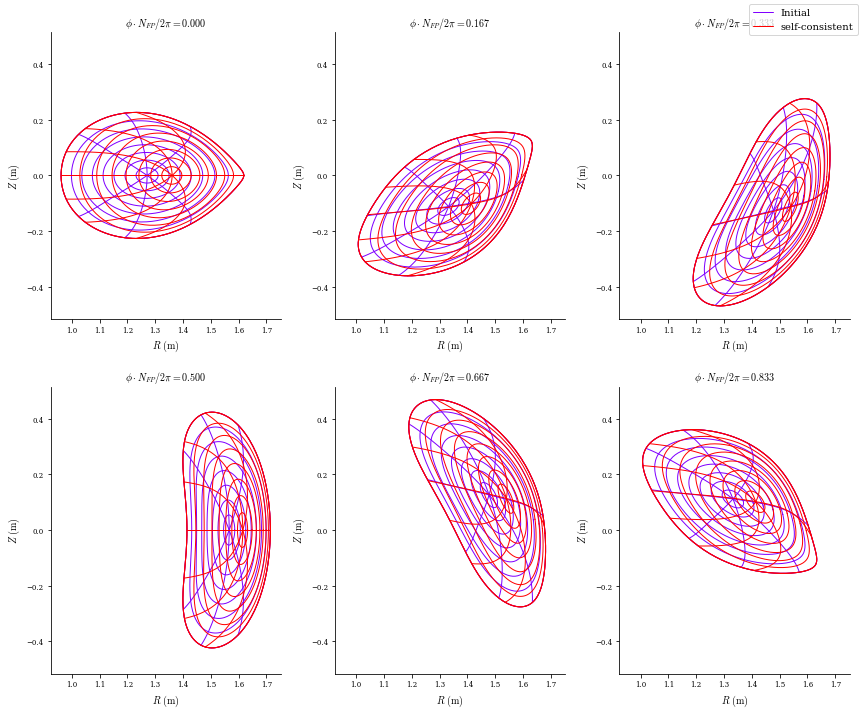

In [6]:
from desc.plotting import plot_comparison

plot_comparison(
    eqs=[eq_init, eq2], labels=["Initial", "self-consistent"]
);

In [7]:
eq = eq2.copy()


In [8]:
solver_config = {
    "OutputFilename": fname,
    "Polynomial_degree": 3,
    "Grid_size": 6,
    "tau": 1.0, 
    "Lower_boundary": 0.0,
    "Upper_boundary": rho_upper,
    "Relative_tolerance": rtol,
    "Absolute_tolerance": [atol],
    "delta_t": 1e-4,
    "MinStepSize": 1e-10,
    "restart": True,
    "solveAdjoint": True, 
    "zeroFlux": True,
    "SteadyStateTolerance": 1e-3,
}
config = {
    "Stellarator": st_config,
    "Solver": solver_config,
}

manta_objective = make_objective(config, vectorized=True)

# def manta_yancc_fun(fields, grid, Vprime):

#     stored_energy, pressure = Objective(fields, grid, Vprime) 

#     return stored_energy, pressure

def objective_from_user_fun(grid, data):
  # note: don't change the signature to this function
    yancc_dat = {
        "B_sup_t": data["B^theta"],
        "B_sup_z": data["B^zeta"],
        "B_sub_t": data["B_theta"],
        "B_sub_z": data["B_zeta"],
        "Bmag": data["|B|"],
        "dBdt": data["|B|_t"],
        "dBdz": data["|B|_z"],
        "sqrtg": data["sqrt(g)"],
    }

    yancc_dat = {
        key: grid.meshgrid_reshape(val, "rtz") for key, val in yancc_dat.items()
    }

    yancc_dat["Psi"] = grid.compress(
        data["Psi"] / grid.nodes[:, 0] ** 2, surface_label="rho"
    )
    yancc_dat["a_minor"] = jnp.full(grid.num_rho, data["a"])
    yancc_dat["R_major"] = jnp.full(grid.num_rho, data["R0"])
    yancc_dat["iota"] = grid.compress(data["iota"], surface_label="rho")
    yancc_dat["rho"] = grid.compress(grid.nodes[:, 0], surface_label="rho")

    V = grid.compress(data['V(r)'])
    V_r = grid.compress(data['V_r(r)'])
    V_rr = grid.compress(data['V_rr(r)'])
    Vp = V_r/V[-1]
    Vpp = V_rr/V[-1]
    
    fields = jax.vmap(lambda d: yancc.field.Field(**d, NFP=grid.NFP))(yancc_dat)

    desc_pressure = grid.compress(data["p"], surface_label="rho")
    
    stored_energy, manta_pressure = manta_objective((fields, Vp, Vpp), grid)
    print("------------ STORED ENERGY ----------------")
    print(stored_energy)
    print("-------------------------------------------")
    
    pressure_error = manta_pressure - desc_pressure # not sure if the sign makes the difference here

    print("------------TOTAL PRESSURE ERROR-----------")
    print(pressure_error)
    print("-------------------------------------------")

    # optimization is easiest for least squares objectives, so instead of maximizing
    # stored energy we minimize 1/stored_energy^2 (the squaring happens later)
    return 1/stored_energy

yancc_desc_grid = yancc_wrapper.grid

# domain_boundary_rho = rho_from_normalized_volume(0.9)
domain_boundary_rho = 1.0
def pressure_constraint_fun(params):
    # function to fix dp/dr=0 at axis and p=0 at edge
    # can modify this for other BC (eg fix p at rho=0.8)
    p_l = params["p_l"]
    dp0 = desc_pressure(Grid(jnp.zeros((1, 3)), jitable=True), p_l, dr=1)
    p1 = desc_pressure(Grid(jnp.zeros((1, 3)).at[0, 0].set(domain_boundary_rho), jitable=True), p_l)
    return jnp.array([dp0, p1]).squeeze()


pressure_constraint_target = jnp.array([0.0, 0.0])
# pressure_constraint_target = jnp.array([0.0, st.getPressure([0.9])[0]])

In [ ]:

# other objectives are non-dimensionalized, so weights should account for that
# and handle relative weighting, this will likely need trial and error
# pressure_error_weight = jnp.full(yancc_desc_grid.num_rho, 1e-5)
stored_energy_weight = 10.0
objective_from_user_weight = stored_energy_weight#jnp.append(stored_energy_weight)

objectives = [
    # AspectRatio(eq=eq, target=6, weight=10),
    Volume(eq=eq, target=V0, weight=1.0),
    # RotationalTransform(eq=eq, target=0.42, weight=10),
    ObjectiveFromUser(
        objective_from_user_fun,
        eq,
        target=0,
        weight=objective_from_user_weight,
        grid=yancc_desc_grid,
        deriv_mode="fwd", 
        # need this assuming manta only has vjp, if using jvp switch to fwd
    ),
]
constraints = [
    ForceBalance(eq=eq),  # J x B - grad(p) = 0
    FixCurrent(eq=eq),  # fix zero current, eventually should use real bootstrap
    # Volume(eq=eq, target=V0), # fix volume of outer flux surface
    FixPsi(eq=eq),  # fix total magnetic flux
    LinearObjectiveFromUser(
        pressure_constraint_fun, eq, target=pressure_constraint_target
    ),
]

objective = ObjectiveFunction(objectives)
objective.build(use_jit=False)
# print(objective.jac_scaled(objective.x(eq)))
eq, info_out = eq.optimize(
    objective=objective,
    constraints=constraints,
    optimizer="proximal-lsq-exact",
    maxiter=5,
    ftol=1e-2,  # stopping tolerance on the function value
    xtol=1e-2,  # stopping tolerance on the step size
    gtol=1e-2,  # stopping tolerance on the gradient
    options={
        "initial_trust_radius": 0.1,   
    # #     # "perturb_options": {"order": 2, "verbose": 3},  # use 2nd-order perturbations
    # #     # "solve_options": {
    # #     #     "ftol": 5e-3,
    # #     #     "xtol": 1e-6,
    # #     #     "gtol": 1e-6,
    # #     #     "verbose": 3,
        },  # for equilibrium subproblem
    # },
    verbose=3,
    copy=True,
)

eq_optimized = eq.copy()

Building objective: volume
Precomputing transforms
Building objective: Custom
Flux norm : JitTracer(~float64[])
yancc_wrapper initialized successfully.
configuring
Successfully created StellaratorTransport object
------------ STORED ENERGY ----------------
JitTracer(float32[])
-------------------------------------------
------------TOTAL PRESSURE ERROR-----------
JitTracer(float64[24])
-------------------------------------------
Building objective: force
Precomputing transforms


Total HDG degrees of freedom 79
Configuration done.


Timer: Precomputing transforms = 106 ms
Timer: Objective build = 122 ms
Timer: Objective build = 1.67 ms
Timer: Eq Update LinearConstraintProjection build = 156 ms
Timer: Proximal projection build = 1.63 sec
Building objective: fixed current
Building objective: fixed Psi
Building objective: custom linear
Timer: Objective build = 1.05 sec
Timer: LinearConstraintProjection build = 212 ms
Number of parameters: 313
Number of objectives: 2
Timer: Initializing the optimization = 2.98 sec

Starting optimization
Using method: proximal-lsq-exact
Flux norm : 146419.5551768456
yancc_wrapper initialized successfully.
configuring
Successfully created StellaratorTransport object


Total HDG degrees of freedom 79
Configuration done.
Setting initial conditions
Residual norm at t = 0: 0
Residual norm at t = 0: 2.88627e+09
Residual norm at t = 0: 0.0686527


Number of Residual Evaluations due to IDACalcIC 3


...

Residual norm at t = 0.0070174: 0.392535
Residual norm at t = 0.0070174: 37.6745
Residual norm at t = 0.00664471: 19.1199
Residual norm at t = 0.00664471: 1.58019


Writing output at 0.0066 ( 85 timesteps )


Residual norm at t = 0.00676894: 0.45438
Residual norm at t = 0.00676894: 2.35575


Writing output at 0.0067 ( 86 timesteps )


Residual norm at t = 0.00686297: 0.0813669


In [ ]:
# final self consistency 
fig, ax = plt.subplots()
niters = 2
for k in range(niters):
    eq = eq.copy()

    fig, ax = plot_1d(eq, "pressure", label="DESC " + str(k), ax=ax)

    yancc_wrapper = yancc_data.from_eq(points, eq=eq2, nt = yancc_ntheta, nz = yancc_nzeta)
 
    st = StellaratorTransport(config, yancc_wrapper=yancc_wrapper)
    st.run()
    
    pi = st.getPressure()

    pi_manta = jnp.concatenate([jnp.array([pi[0]]), pi, jnp.zeros(1)])
    ax.plot(pressure_rho, pi_manta, label="MANTA" + str(k))
    eq.pressure = SplineProfile(pi_manta, pressure_rho)
    # fit the current profile to a power series, with c_0=c_1=0
    # XX = np.fliplr(np.vander(rho, eq2.L + 1)[:, :-2])
    # eq2.c_l = np.pad(np.linalg.lstsq(XX, current, rcond=None)[0], (2, 0))
    # re-solve the equilibrium
    eq, _ = eq.solve(objective="force", optimizer="lsq-exact", verbose=3)


ax.legend()
eq_optimized_self_consistent = eq.copy()

In [ ]:
eq_optimized_self_consistent.save(eq_name + "optimized_equilibrium.h5")

In [ ]:
from desc.plotting import plot_comparison

plot_comparison(
    eqs=[eq_init, eq], labels=["Initial", "self-consistent"]
);

In [ ]:
from desc.plotting import plot_boundaries

plot_comparison(
    eqs=[eq_init, eq_optimized, eq], labels=["Initial", "optimized", "self-consistent"]
);

In [ ]:
plot_boundaries(
    eqs=[eq_init, eq_optimized, eq], labels=["Initial", "optimized", "self-consistent"]
);

In [ ]:
from desc.plotting import plot_boozer_surface, plot_boundaries, plot_qs_error
# eq = desc.io.load("../python/eq2optimized_equilibrium.h5")#desc.examples.get("ESTELL")
# plot_boozer_surface(eq_init, fieldlines=8)
plot_boozer_surface(eq, fieldlines=8)
# plot_qs_error(eq_init)
plot_qs_error(eq)